## Import Required Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.ticker import ScalarFormatter

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

## Configuration
Specify city and data paths

In [27]:
# Configuration
CITY = "paris"  # Change this to process different cities
BASE_DIR = Path(f"/data/workspaces/fbellisardi/data_processed/{CITY}")

# Try multiple possible CSV file locations (with fallback)
POSSIBLE_CSV_FILES = [
    BASE_DIR / "graphs_fine_grid" / "fine_grid_gravitational_work.csv",
    BASE_DIR / "graphs_fine_grid" / "gravitational_work_by_variant.csv",
    BASE_DIR / "graphs" / "fine_grid_gravitational_work.csv",
    BASE_DIR / "graphs" / "gravitational_work_by_variant.csv",
]

CSV_FILE = None
for csv_path in POSSIBLE_CSV_FILES:
    if csv_path.exists():
        CSV_FILE = csv_path
        print(f"✓ Found data file: {csv_path}")
        break

if CSV_FILE is None:
    print("❌ No CSV file found. Tried:")
    for p in POSSIBLE_CSV_FILES:
        print(f"  - {p}")
    raise FileNotFoundError("No gravitational work CSV file found")

print(f"\nCity: {CITY}")
print(f"Using: {CSV_FILE.name}")

✓ Found data file: /data/workspaces/fbellisardi/data_processed/paris/graphs_fine_grid/fine_grid_gravitational_work.csv

City: paris
Using: fine_grid_gravitational_work.csv


## Load Data

In [28]:
# Read CSV data
df = pd.read_csv(CSV_FILE)
print(f"\nData shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

# Normalize CSV format to ensure consistent structure
# Expected columns: variant_type, parameter, work_wd, work_hol, total_work
if 'variant' in df.columns and 'variant_type' not in df.columns:
    print("\n⚠ Converting 'variant' format to 'variant_type' format...")
    
    def parse_variant_to_type(variant):
        """Convert variant names to (variant_type, parameter) tuple."""
        variant_lower = variant.lower()
        
        if variant_lower == 'original':
            return 'original', 0
        
        # Rotation: rot_+45deg or rot_-90deg
        if 'rot' in variant_lower:
            import re
            match = re.search(r'([+-]?\d+\.?\d*)', variant)
            if match:
                angle = float(match.group(1))
                return 'rotation', angle
        
        # Translation: trans_1000m_a90 or translated_1
        if 'trans' in variant_lower:
            import re
            # Check for distance_angle format
            dist_match = re.search(r'(\d+)m', variant)
            angle_match = re.search(r'a(\d+)', variant)
            
            if dist_match and angle_match:
                distance = int(dist_match.group(1))
                angle = int(angle_match.group(1))
                return f'translation_{angle}', distance
            elif dist_match:
                # Just distance, no angle
                distance = int(dist_match.group(1))
                return 'translation_0', distance
            else:
                # Generic translation
                num_match = re.search(r'(\d+)', variant)
                if num_match:
                    return 'translation_0', int(num_match.group(1))
        
        return 'other', 0
    
    # Convert each variant
    parsed = df['variant'].apply(parse_variant_to_type)
    df['variant_type'] = parsed.apply(lambda x: x[0])
    df['parameter'] = parsed.apply(lambda x: x[1])
    print(f"  ✓ Converted {len(df)} variants")

# Ensure total_work column exists
if 'total_work' not in df.columns:
    if 'work_wd' in df.columns and 'work_hol' in df.columns:
        df['total_work'] = df['work_wd'] + df['work_hol']
        print("  ✓ Created total_work column from work_wd + work_hol")
    else:
        print("  ❌ Missing work columns!")

print(f"\nFirst few rows:")
df.sort_values(by='total_work', ascending=True, inplace=True)
df.head()


Data shape: (18, 6)
Columns: ['filename', 'variant_type', 'parameter', 'total_work', 'num_nodes', 'num_edges']

First few rows:


,filename,variant_type,parameter,total_work,num_nodes,num_edges
0,graph_original.pkl,original,0.0,1.464365e+07,440673,1007946
3,graph_rot_+20p00deg.pkl,rotation,20.0,1.634050e+07,440673,1007946
2,graph_rot_+15p00deg.pkl,rotation,15.0,1.645987e+07,440673,1007946
1,graph_rot_+10p00deg.pkl,rotation,10.0,1.684454e+07,440673,1007946
12,graph_trans_499m_a+255.pkl,translation_255,499.0,1.715659e+07,440673,1007946


## Explore Data

In [29]:
# Data overview
print("Variant types:")
print(df['variant_type'].value_counts())
# print(f"\nTotal work range: {df['total_work'].min():,.0f} - {df['total_work'].max():,.0f} J")

# Separate by type
df_rotation = df[df['variant_type'] == 'rotation'].copy()
df_original = df[df['variant_type'] == 'original'].copy()
print(f"\nRotation variants: {len(df_rotation)}")
print(f"Original variants: {len(df_original)}")
print(f"Translation variants: {len(df) - len(df_rotation) - len(df_original)}")

Variant types:
variant_type
rotation           6
translation_255    5
translation_075    5
original           2
Name: count, dtype: int64

Rotation variants: 6
Original variants: 2
Translation variants: 10


## Create Plots
Generate the three main plots: Rotation, Translation N-S, Translation W-E

In [30]:
# Shared font sizes for plots
AXIS_LABEL_SIZE = 18
AXIS_LABEL_WEIGHT = 'normal'
TICK_LABEL_SIZE = 18
ANNOTATION_SIZE = 14
LEGEND_SIZE = 14
parabolic_fit = False

In [31]:
# Prepare translation data - separate by direction
# 0°=East, 90°=North, 180°=West, 270°=South (but 270° becomes -90° in data)
translation_types = [vt for vt in df['variant_type'].unique() if vt.startswith('translation_')]

df_trans_ns = []  # North-South: angles close to 90° and 270°
df_trans_we = []  # West-East: angles close to 0° and 180°

for trans_type in translation_types:
    angle = int(trans_type.split('_')[1])
    df_trans = df[df['variant_type'] == trans_type].copy()
    
    # North-South: 90° ±45° (45-135°) and 270° ±45° (225-315°)
    if (45 <= angle <= 135) or (225 <= angle <= 315):
        df_trans_ns.append(df_trans)
    # West-East: 0° ±45° (315-45°) and 180° ±45° (135-225°)
    else:
        df_trans_we.append(df_trans)

df_trans_ns = pd.concat(df_trans_ns, ignore_index=True) if df_trans_ns else pd.DataFrame()
df_trans_we = pd.concat(df_trans_we, ignore_index=True) if df_trans_we else pd.DataFrame()

print(f"N-S translations: {len(df_trans_ns)}")
print(f"W-E translations: {len(df_trans_we)}")

N-S translations: 10
W-E translations: 0


## Summary Statistics

In [32]:
# Print summary statistics
print("="*60)
print("GRAVITATIONAL WORK SUMMARY")
print("="*60)

# Original
if len(df_original) > 0:
    orig_work = df_original['total_work'].values[0]
    # print(f"\nOriginal configuration work: {orig_work:,.0f} J·m")

# By type
for variant_type in df['variant_type'].unique():
    if variant_type == 'original':
        continue
    
    df_var = df[df['variant_type'] == variant_type]
    print(f"\n{variant_type}:")
    print(f"  Count: {len(df_var)}")
    print(f"  Min work: {df_var['total_work'].min():,.0f} J·m")
    print(f"  Max work: {df_var['total_work'].max():,.0f} J·m")
    print(f"  Mean work: {df_var['total_work'].mean():,.0f} J·m")
    
    if len(df_original) > 0:
        pct_change = ((df_var['total_work'] - orig_work) / orig_work * 100)
        print(f"  Change from original: {pct_change.min():.1f}% to {pct_change.max():.1f}%")

print("\n" + "="*60)

GRAVITATIONAL WORK SUMMARY

rotation:
  Count: 6
  Min work: 16,340,497 J·m
  Max work: 334,871,536 J·m
  Mean work: 122,189,438 J·m
  Change from original: 11.6% to 2186.8%

translation_255:
  Count: 5
  Min work: 17,156,591 J·m
  Max work: 17,877,675 J·m
  Mean work: 17,705,865 J·m
  Change from original: 17.2% to 22.1%

translation_075:
  Count: 5
  Min work: 17,212,459 J·m
  Max work: 18,107,700 J·m
  Mean work: 17,837,533 J·m
  Change from original: 17.5% to 23.7%



## Export Plots

ValueError: x and y must be the same size

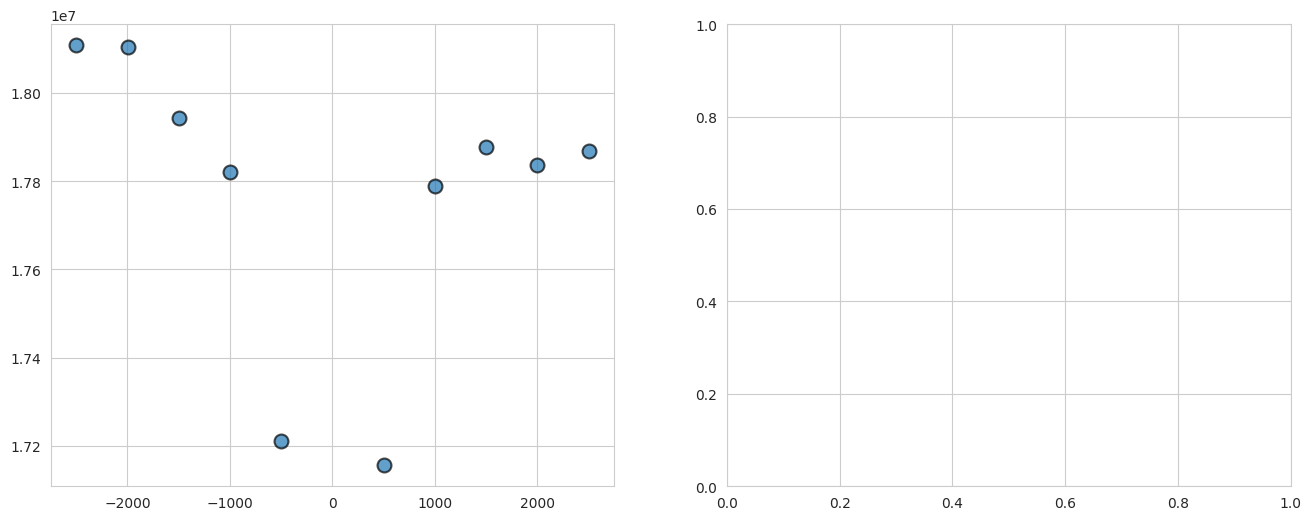

In [33]:
# Save plots to files (recreate the figure to save)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare shared y-axis formatter to display ×10^y
sci_formatter = ScalarFormatter(useMathText=True)
sci_formatter.set_powerlimits((8, 8))

# Minimum distance threshold from origin
MIN_DISTANCE_M = 50  # 1 km in meters
MIN_ANGLE_DEG = 1      # 1 degree for rotations

# 2. Unified Translation plot - all directions in one graph
ax = axes[0]
color_map = {
    'north': '#1f77b4',   # blue
    'south': '#1f77b4',   # blue (same as north)
    'east': '#d62728',    # red
    'west': '#d62728'     # red (same as east)
}
label_map = {
    'north': 'N-S',
    'south': 'N-S',
    'east': 'W-E',
    'west': 'W-E'
}
seen_labels = set()
orig_work = df_original['total_work'].iloc[0] if len(df_original) > 0 else None

# Plot all translation types with unified coloring
# Filter out configurations with work lower than original
if len(df_trans_ns) > 0 or len(df_trans_we) > 0:
    all_trans = pd.concat([df_trans_ns, df_trans_we], ignore_index=True)
    
    # Filter: keep only configurations with work >= original (exclude better ones)
    # AND with distance >= 1 km
    # if orig_work is not None:
    #     all_trans = all_trans[all_trans['total_work'] >= orig_work].copy()
    all_trans = all_trans[all_trans['parameter'] >= MIN_DISTANCE_M].copy()

    for trans_type in all_trans['variant_type'].unique():
        angle = int(trans_type.split('_')[1])
        df_subset = all_trans[all_trans['variant_type'] == trans_type]

        # Determine direction and color
        if 225 <= angle <= 315:  # South
            direction = 'south'
            x_vals = df_subset['parameter']  # positive = right (S on right)
        elif 45 <= angle <= 135:  # North
            direction = 'north'
            x_vals = -df_subset['parameter']  # negative = left (N on left)
        elif 135 <= angle <= 225:  # West
            direction = 'west'
            x_vals = -df_subset['parameter']  # negative = left (W on left)
        else:  # East (0° and around)
            direction = 'east'
            x_vals = df_subset['parameter']  # positive = right (E on right)

        # Scatter
        lbl = label_map[direction] if label_map[direction] not in seen_labels else None
        ax.scatter(x_vals, df_subset['total_work'],
                  s=100, alpha=0.7, c=color_map[direction],
                  edgecolors='black', linewidth=1.5, label=lbl)
        if lbl:
            seen_labels.add(lbl)

        if parabolic_fit:
            # Fit parabola with vertex at origin: y = a*x^2 + orig_work
            df_sort = df_subset.copy()
            df_sort['x_plot'] = x_vals.values
            
            if orig_work is not None and len(df_sort) > 0:
                # Include origin point in the fit
                x_data = np.append(df_sort['x_plot'].values, 0)
                y_data = np.append(df_sort['total_work'].values, orig_work)
                
                # Fit parabola: minimize sum((y - (a*x^2 + orig_work))^2)
                # Analytical solution: a = sum((y - orig_work) * x^2) / sum(x^4)
                x_squared = x_data ** 2
                numerator = np.sum((y_data - orig_work) * x_squared)
                denominator = np.sum(x_data ** 4)
                if denominator > 0:
                    a = numerator / denominator
                    
                    # Generate smooth parabola
                    x_range = np.linspace(df_sort['x_plot'].min(), df_sort['x_plot'].max(), 100)
                    y_parabola = a * x_range**2 + orig_work
                    
                    ax.plot(x_range, y_parabola, 
                           color=color_map[direction], alpha=0.6, linewidth=2, linestyle='--')

# Add original point
if len(df_original) > 0:
    ax.scatter([0], df_original['total_work'].values,
              s=500, alpha=0.9, c='red', marker='*',
              edgecolors='darkred', linewidth=2,
              label='Original', zorder=10)

# Get axis limits for annotation placement
xlim = ax.get_xlim()
ylim = ax.get_ylim()
y_bottom = ylim[0] - (ylim[1] - ylim[0]) * 0.08

# Add direction labels at bottom
ax.text(xlim[0], y_bottom, 'N|W', fontsize=ANNOTATION_SIZE, fontweight='bold',
        ha='left', va='top', transform=ax.transData)
ax.text(xlim[1], y_bottom, 'S|E', fontsize=ANNOTATION_SIZE, fontweight='bold',
        ha='right', va='top', transform=ax.transData)

ax.set_xlabel('Translation Distance (m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.set_major_formatter(sci_formatter)
ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
ax.legend(loc='lower right', fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)

# 1. Rotation plot - centered at 0 with symmetric angles
ax = axes[1]
if len(df_rotation) > 0:
    # Filter: keep only rotations with work >= original (exclude better ones)
    # AND with |angle| >= MIN_ANGLE_DEG
    df_rot_filtered = df_rotation.copy()
    # if orig_work is not None:
    #     df_rot_filtered = df_rot_filtered[df_rot_filtered['total_work'] >= orig_work].copy()
    df_rot_filtered = df_rot_filtered[df_rot_filtered['parameter'].abs() >= MIN_ANGLE_DEG].copy()
    
    # Convert angles > 180 to negative for symmetry: 270 -> -90, etc.
    df_rot_plot = df_rot_filtered.copy()
    df_rot_plot['parameter'] = df_rot_plot['parameter'].apply(
        lambda x: x - 360 if x > 180 else x
    )

    ax.scatter(df_rot_plot['parameter'], df_rot_plot['total_work'],
              s=100, alpha=0.7, c='steelblue', edgecolors='black', linewidth=1.5, label='Rotation')

    # Connect rotation points, including origin
    df_rot_line = df_rot_plot.copy()
    if len(df_original) > 0:
        df_rot_line = pd.concat([
            df_rot_line,
            df_original.assign(parameter=0)
        ], ignore_index=True)
    df_rot_line = df_rot_line.sort_values('parameter')
    # ax.plot(df_rot_line['parameter'], df_rot_line['total_work'],
    #         color='steelblue', alpha=0.6, linewidth=1.5)

    # Add original point at center
    if len(df_original) > 0:
        ax.scatter([0], df_original['total_work'].values,
                  s=500, alpha=0.9, c='red', marker='*',
                  edgecolors='darkred', linewidth=2,
                  label='Original', zorder=10)

ax.set_xlabel('Rotation Angle (degrees)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
ax.yaxis.set_major_formatter(sci_formatter)
ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)


plt.tight_layout()

# Save as PNG
output_dir = "/home/fbellisardi/code/topolity/output" + f"/{CITY}/" + "graphs_fine_grid"
if not Path(output_dir).exists():
    Path(output_dir).mkdir(parents=True, exist_ok=True)
png_file = output_dir + "/fine_grid_gravitational_work.png"
plt.savefig(png_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {png_file}")

# Save as PDF
pdf_file = output_dir + "/fine_grid_gravitational_work.pdf"
plt.savefig(pdf_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {pdf_file}")

# plt.show()

# Fine Grid Gravitational Work — CSV Analysis
This section reads the results CSV produced by `fine_grid_gravitational_work.py` and generates summary tables and plots.

In [34]:
# Imports + choose city
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Choose city to analyze (must match data_processed/<city>)
base_dir = Path("/home/fbellisardi/code/topolity/data/data_processed")
graphs_dir = base_dir / CITY / "graphs_fine_grid"
csv_path = graphs_dir / "fine_grid_gravitational_work.csv"
print("CSV:", csv_path)

# Load results CSV
df = pd.read_csv(csv_path)
if "filename" in df.columns:
    df = df.drop_duplicates(subset=["filename"], keep="last").reset_index(drop=True)

print("Rows:", len(df))
print("Columns:", list(df.columns))
df

CSV: /home/fbellisardi/code/topolity/data/data_processed/paris/graphs_fine_grid/fine_grid_gravitational_work.csv
Rows: 15
Columns: ['filename', 'variant_type', 'parameter', 'total_work', 'num_nodes', 'num_edges']


,filename,variant_type,parameter,total_work,num_nodes,num_edges
0,graph_rot_+20p00deg.pkl,rotation,20.0,1.634050e+07,440673,1007946
1,graph_rot_+5p00deg.pkl,rotation,5.0,1.744005e+07,440673,1007946
2,graph_trans_1500m_a+075.pkl,translation_075,1500.0,1.794232e+07,440673,1007946
3,graph_trans_1500m_a+255.pkl,translation_255,1500.0,1.787768e+07,440673,1007946
4,graph_trans_1999m_a+075.pkl,translation_075,1999.0,1.810469e+07,440673,1007946
5,graph_trans_1999m_a+255.pkl,translation_255,1999.0,1.783632e+07,440673,1007946
6,graph_trans_2500m_a+075.pkl,translation_075,2500.0,1.810770e+07,440673,1007946
7,graph_trans_2500m_a+255.pkl,translation_255,2500.0,1.786931e+07,440673,1007946
8,graph_trans_499m_a+075.pkl,translation_075,499.0,1.721246e+07,440673,1007946
9,graph_trans_499m_a+255.pkl,translation_255,499.0,1.715659e+07,440673,1007946


In [35]:
# Summary + sanity checks
assert {"filename","variant_type","parameter","total_work"}.issubset(df.columns), "Unexpected CSV schema"

print("Variants:", df["variant_type"].unique().tolist())
print("Total work stats → min:", df["total_work"].min(), "max:", df["total_work"].max(), "mean:", df["total_work"].mean())
print("By variant type:")
print(df.groupby("variant_type")["total_work"].agg(["count","min","max","mean"]))

# Warn if all zeros
if float(df["total_work"].sum()) == 0.0:
    print("WARNING: all total_work values are 0. Check DEM or OD mapping.")

Variants: ['rotation', 'translation_075', 'translation_255', 'original']
Total work stats → min: 16340497.379989617 max: 334871536.0 mean: 76934987.82798941
By variant type:
                 count           min           max          mean
variant_type                                                    
original             1  2.764756e+08  2.764756e+08  2.764756e+08
rotation             4  1.634050e+07  3.348715e+08  1.749581e+08
translation_075      5  1.721246e+07  1.810770e+07  1.783753e+07
translation_255      5  1.715659e+07  1.787768e+07  1.770586e+07


NameError: name 'output_dir' is not defined

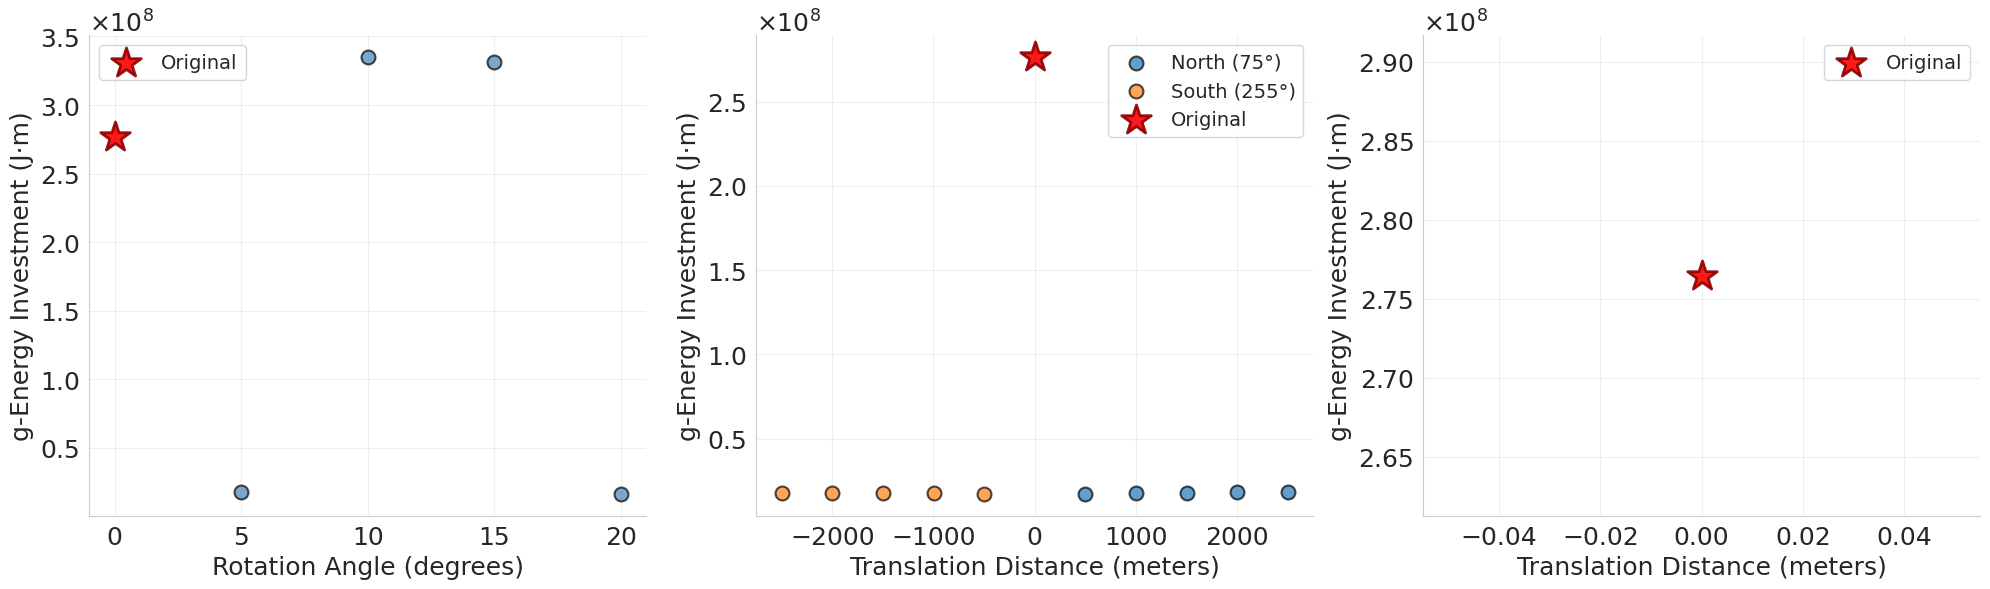

In [36]:
# Plots (rotation, translation N/S, translation W/E)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 6)

# Minimum distance threshold from origin
MIN_DISTANCE_M = 100  # 50 meters
MIN_ANGLE_DEG = 1      # 1 degree for rotations

df_rotation = df[df['variant_type'] == 'rotation'].copy()
df_original = df[df['variant_type'] == 'original'].copy()
translation_types = [vt for vt in df['variant_type'].unique() if vt.startswith('translation_')]

df_trans_ns_list, df_trans_we_list = [], []
for trans_type in translation_types:
    angle = int(trans_type.split('_')[1])
    df_trans = df[df['variant_type'] == trans_type].copy()
    if (45 <= angle <= 135) or (225 <= angle <= 315):
        df_trans_ns_list.append(df_trans)
    else:
        df_trans_we_list.append(df_trans)

df_trans_ns = pd.concat(df_trans_ns_list, ignore_index=True) if df_trans_ns_list else pd.DataFrame()
df_trans_we = pd.concat(df_trans_we_list, ignore_index=True) if df_trans_we_list else pd.DataFrame()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Rotation
ax = axes[0]
if len(df_rotation) > 0:
    # Filter: keep only rotations with |angle| >= MIN_ANGLE_DEG
    df_rot_filtered = df_rotation[df_rotation['parameter'].abs() >= MIN_ANGLE_DEG].copy()
    ax.scatter(df_rot_filtered['parameter'], df_rot_filtered['total_work'], s=100, alpha=0.7, c='steelblue', edgecolors='black', linewidth=1.5)
    if len(df_original) > 0:
        ax.scatter([0], df_original['total_work'].values, s=500, alpha=0.9, c='red', marker='*', edgecolors='darkred', linewidth=2, label='Original', zorder=10)
ax.set_xlabel('Rotation Angle (degrees)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
ax.yaxis.set_major_formatter(sci_formatter)
ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)

# Translation N/S
ax = axes[1]
if len(df_trans_ns) > 0:
    # Filter: keep only translations with distance >= MIN_DISTANCE_M
    df_trans_ns_filtered = df_trans_ns[df_trans_ns['parameter'] >= MIN_DISTANCE_M].copy()
    for trans_type in df_trans_ns_filtered['variant_type'].unique():
        angle = int(trans_type.split('_')[1])
        df_subset = df_trans_ns_filtered[df_trans_ns_filtered['variant_type'] == trans_type]
        if 225 <= angle <= 315:
            ax.scatter(-df_subset['parameter'], df_subset['total_work'], s=100, alpha=0.7, edgecolors='black', linewidth=1.5, label=f'South ({angle}°)')
        else:
            ax.scatter(df_subset['parameter'], df_subset['total_work'], s=100, alpha=0.7, edgecolors='black', linewidth=1.5, label=f'North ({angle}°)')
if len(df_original) > 0:
    ax.scatter([0], df_original['total_work'].values, s=500, alpha=0.9, c='red', marker='*', edgecolors='darkred', linewidth=2, label='Original', zorder=10)
ax.set_xlabel('Translation Distance (meters)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
ax.yaxis.set_major_formatter(sci_formatter)
ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)

# Translation W/E
ax = axes[2]
if len(df_trans_we) > 0:
    # Filter: keep only translations with distance >= MIN_DISTANCE_M
    df_trans_we_filtered = df_trans_we[df_trans_we['parameter'] >= MIN_DISTANCE_M].copy()
    for trans_type in df_trans_we_filtered['variant_type'].unique():
        angle = int(trans_type.split('_')[1])
        df_subset = df_trans_we_filtered[df_trans_we_filtered['variant_type'] == trans_type]
        if 135 <= angle <= 225:
            ax.scatter(-df_subset['parameter'], df_subset['total_work'], s=100, alpha=0.7, edgecolors='black', linewidth=1.5, label=f'West ({angle}°)')
        else:
            ax.scatter(df_subset['parameter'], df_subset['total_work'], s=100, alpha=0.7, edgecolors='black', linewidth=1.5, label=f'East ({angle}°)')
if len(df_original) > 0:
    ax.scatter([0], df_original['total_work'].values, s=500, alpha=0.9, c='red', marker='*', edgecolors='darkred', linewidth=2, label='Original', zorder=10)
ax.set_xlabel('Translation Distance (meters)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('g-Energy Investment (J·m)', fontsize=AXIS_LABEL_SIZE, fontweight=AXIS_LABEL_WEIGHT)
ax.tick_params(axis='both', labelsize=TICK_LABEL_SIZE)
ax.yaxis.set_major_formatter(sci_formatter)
ax.yaxis.get_offset_text().set_size(TICK_LABEL_SIZE)
ax.legend(fontsize=LEGEND_SIZE)
ax.grid(True, alpha=0.3)

plt.tight_layout()
png_file = output_dir + "/g_investment.png"
plt.savefig(png_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {png_file}")

# Save as PDF
pdf_file = output_dir + "/g_investment.pdf"
plt.savefig(pdf_file, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {pdf_file}")